# Exploratory Data Analysis

## Импорты

In [2]:
from functools import partial

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from scipy.stats import gaussian_kde
from sklearn.metrics import calinski_harabasz_score

from src.signal_processing.plotting import plot_plain_signal, signals_title, thin, red_dash, basic_line, \
    highlight_line, set_axis_labels, y_label, plot_hist, ax_off, plot_corr_m, split_line, markers
from src.signal_processing.preprocessing import calc_base_signal_components

## Загрузка данных

In [3]:
dataset = pd.read_csv('../data/Run200_Wave_0_1.txt', sep=' ', header=None, skipinitialspace=True)
dataset = dataset.drop([0, 1, 2, 3, 504], axis=1)
dataset.columns = list(range(dataset.shape[1]))

## Ознакомление с данными

In [4]:
data_h = np.hstack(dataset.values)
data_h_sorted = np.sort(data_h)
data_h_nonzero = np.where(data_h_sorted > 0)[0]
signal_count = dataset.shape[0]

In [5]:
dataset.head()

,0,1,2,3,4,5,6,7,8,9,...,490,491,492,493,494,495,496,497,498,499
0,14820,14823,14824,14822,14818,14820,14824,14822,14820,14820,...,14828,14822,14815,14815,14817,14819,14820,14822,14820,14819
1,14820,14822,14820,14826,14824,14822,14820,14822,14823,14821,...,14828,14817,14824,14822,14824,14819,14820,14819,14822,14820
2,14820,14820,14822,14825,14820,14824,14824,14819,14823,14824,...,14820,14821,14820,14820,14818,14821,14823,14820,14820,14821
3,14828,14822,14818,14824,14824,14822,14820,14822,14824,14820,...,14824,14826,14822,14821,14820,14828,14820,14822,14823,14822
4,14823,14815,14823,14821,14827,14820,14823,14824,14816,14821,...,14820,14820,14823,14828,14824,14820,14824,14824,14822,14825


In [6]:
print(f"Размерность: {dataset.shape}")
print(f"Отсутствующих значений: {np.sum(dataset.isna())}")
print(f"min: {data_h.min()}")
print(f"Кол-во нулевых значений: {(data_h_sorted == 0).sum()}")
print(f"Первые 10 ненулевых значений: {data_h_sorted[data_h_nonzero][:10]}")
print(f"p05: {np.percentile(data_h, 5)}")
print(f"p25: {np.percentile(data_h, 25)}")
print(f"mean: {data_h.mean()}")
print(f"p50: {np.percentile(data_h, 50)}")
print(f"p75: {np.percentile(data_h, 75)}")
print(f"max: {data_h.max()}")

Размерность: (23479, 500)
Отсутствующих значений: 0
min: 0
Кол-во нулевых значений: 16
Первые 10 ненулевых значений: [ 25  29  52  72 311 337 530 674 740 767]
p05: 14786.0
p25: 14818.0
mean: 14796.683723582775
p50: 14822.0
p75: 14824.0
max: 14838


<Axes: title={'center': 'Signals'}, xlabel='Time, ns', ylabel='Bit ADC'>

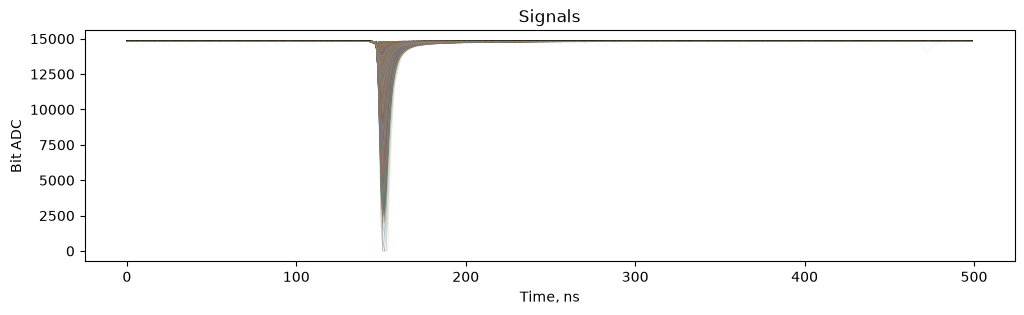

In [7]:
plot_plain_signal(dataset.iloc[:, :1000].T, **signals_title, **thin)

## Инверсия сигналов
Инвертируем сигналы, чтобы все сигналы начинались от 0.

In [8]:
adc_inversion_term = 2 ** 14
df_inverted = (adc_inversion_term - dataset)
min_vals = df_inverted.apply(min, axis=1)
df_raw = df_inverted.sub(min_vals, axis=0)
assert df_raw.min().min() == 0
assert df_raw.shape[0] == signal_count
df_raw.head()

,0,1,2,3,4,5,6,7,8,9,...,490,491,492,493,494,495,496,497,498,499
0,10,7,6,8,12,10,6,8,10,10,...,2,8,15,15,13,11,10,8,10,11
1,8,6,8,2,4,6,8,6,5,7,...,0,11,4,6,4,9,8,9,6,8
2,10,10,8,5,10,6,6,11,7,6,...,10,9,10,10,12,9,7,10,10,9
3,3,9,13,7,7,9,11,9,7,11,...,7,5,9,10,11,3,11,9,8,9
4,5,13,5,7,1,8,5,4,12,7,...,8,8,5,0,4,8,4,4,6,3


Посмотрим на инвертированные сигналы.

<Axes: title={'center': 'Signals'}, xlabel='Time, ns', ylabel='Bit ADC'>

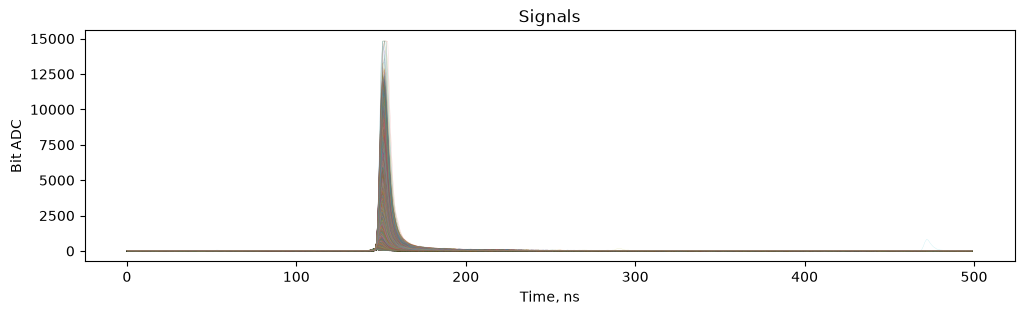

In [10]:
plot_plain_signal(df_raw.iloc[:, :1000].T, **signals_title, **thin)

## Визуализация сигналов
Посмотрим на сигналы поближе.

<Axes: title={'center': 'Signals'}, xlabel='Time, ns', ylabel='Bit ADC'>

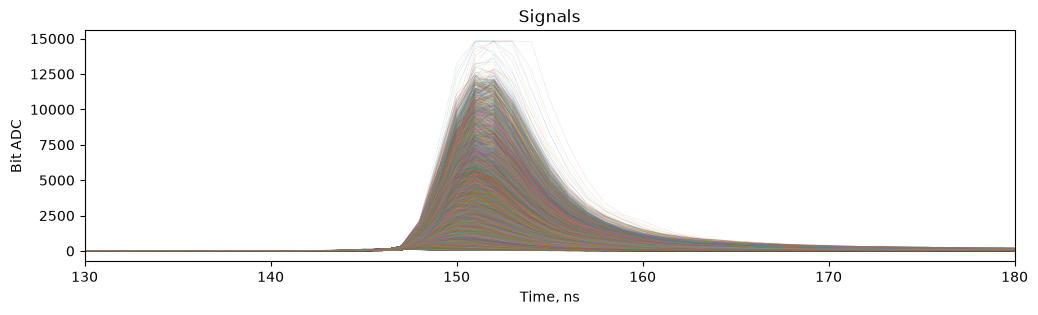

In [11]:
plot_plain_signal(df_raw.iloc[:, :1000].T, xlim=(130, 180), **signals_title, **thin)

### Начальные индексы
Сигналы начинаются, примерно, со 140-141-го индексов.

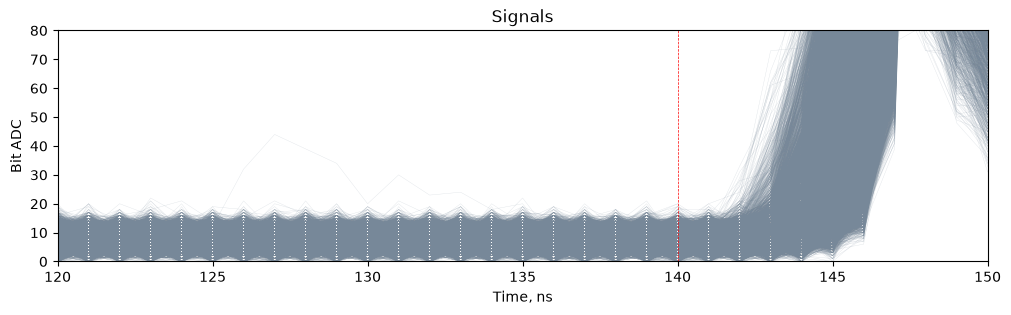

In [26]:
ax = plot_plain_signal(df_raw.iloc[:, :1000].T, xlim=(120, 150), ylim=(0, 80), **signals_title, **basic_line)
ax.vlines(x=[140], ymin=0, ymax=80, **red_dash)

### Шумные сигналы
В датасете есть 2 сигнала, которые "шумят" до 140 индекса.

In [13]:
noisy_signals = df_raw[df_raw.iloc[:, 40:140].max(axis=1) > 30].index.tolist()
noisy_signals

[3321, 11849]

In [14]:
noise_mask = [_ for _ in range(df_raw.shape[0]) if _ not in noisy_signals]
noise_threshold = df_raw.iloc[noise_mask, :140].max().max()
print(f"Уровень шума: {noise_threshold}")

Уровень шума: 24


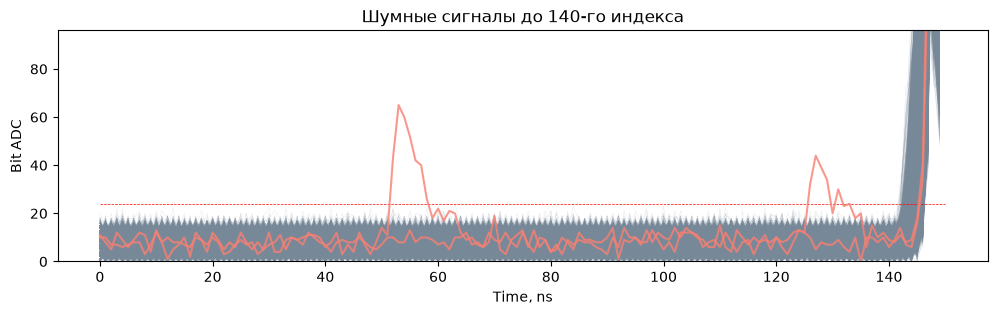

In [15]:
end_idx = 150
x = df_raw.columns[:end_idx]
ax = plot_plain_signal(df_raw.iloc[:, :end_idx].T, ylim=(0, noise_threshold * 4),
                       title="Шумные сигналы до 140-го индекса", **basic_line)
ax.hlines(y=[noise_threshold], xmin=0, xmax=end_idx, **red_dash)
for idx in noisy_signals:
    ax.plot(x, df_raw.iloc[idx, :end_idx], **highlight_line)

### Двойные/плоские пики
Среди сигналов встречаются такие, у которых пики уплощёны. Это важно для определения пика и расчёта времени высвечивания.

In [16]:
max_vals = df_raw.apply(lambda row: len(np.where(row == row.max())[0]), axis=1)
gt_1_peaks = np.where(max_vals > 1)[0]
print(f"Сигналов с уплощёнными пиками: {len(gt_1_peaks)}")

Сигналов с уплощёнными пиками: 212


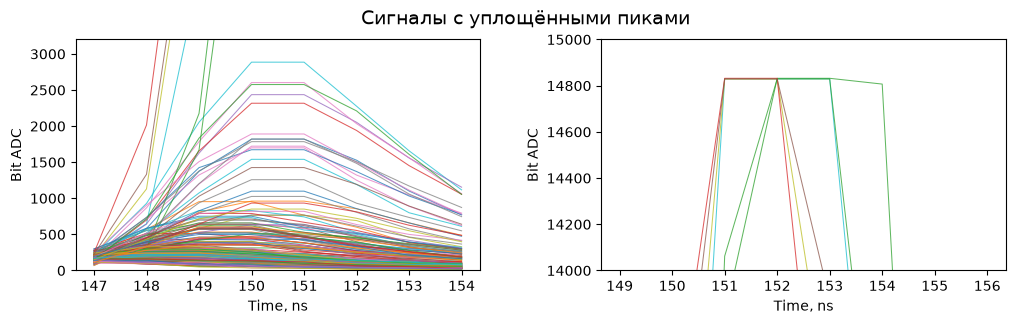

In [17]:
flat_peak_params = dict(title="", legend=None, alpha=0.75, linewidth=0.75)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 3), gridspec_kw={'wspace': 0.3})
fig.suptitle('Сигналы с уплощёнными пиками', fontsize=14)
df_raw.iloc[gt_1_peaks, 147:155].T.plot(**flat_peak_params, ax=ax1)
df_raw.iloc[gt_1_peaks, 149:157].T.plot(**flat_peak_params, ax=ax2)
ax1.set_ylim(0, 3200)
ax2.set_ylim(14000, 15000)
set_axis_labels(ax1)
set_axis_labels(ax2)

## Гистограмма пиков

In [18]:
max_amps = df_raw.apply(np.max, axis=1)

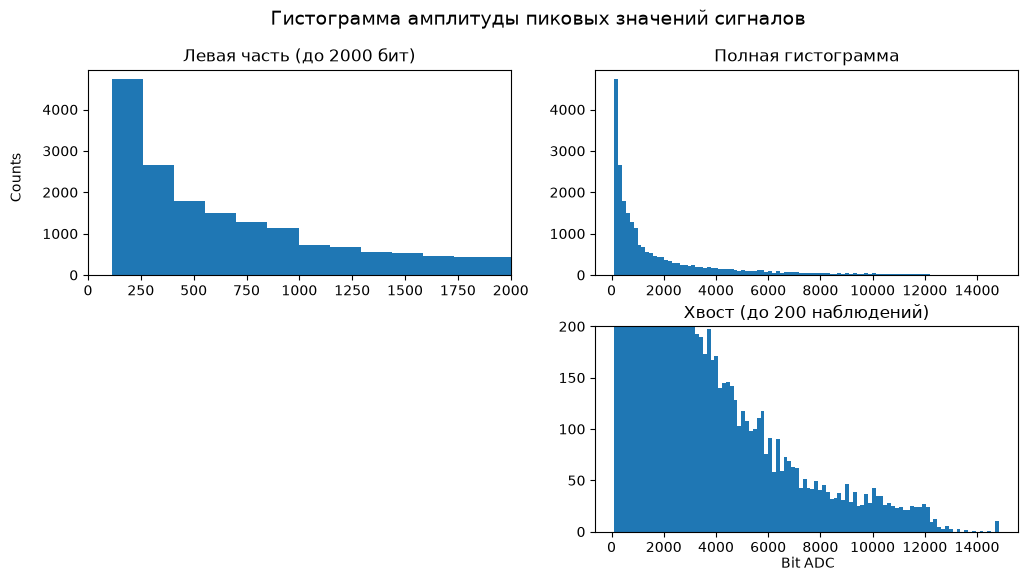

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(12, 6), gridspec_kw={'wspace': 0.2, 'hspace': 0.25})
fig.suptitle("Гистограмма амплитуды пиковых значений сигналов", fontsize=14, y=0.98)
axes[0][0].hist(max_amps, bins=100)
axes[0][0].set_title("Левая часть (до 2000 бит)")
axes[0][0].set_xlim(0, 2000)
axes[0][1].hist(max_amps, bins=100)
axes[0][1].set_title("Полная гистограмма")
axes[1][0].axis('off')
axes[1][1].hist(max_amps, bins=100)
axes[1][1].set_title("Хвост (до 200 наблюдений)")
axes[1][1].set_ylim(0, 200)
fig.text(0.725, 0.05, y_label, ha='center')
fig.text(0.06, 0.7, "Counts", va='center', rotation='vertical')
plt.show()

### Двойные сигналы 1929, 19696
В датасете есть двойные сигнал. Их индекс - 1929 и 19696. 
Скорее всего, это аномалии. В обычных условиях, их можно было бы либо удалить, либо разрезать на 2 части. 
Но т.к. нам требуется отнести это сигнал к какому-то кластеру, то для расчётов возьмём первые сигнал, а при кластеризации выставим им неопределённый кластер.

In [20]:
signal_peaks = df_raw.apply(np.argmax, axis=1)
signal_with_far_peak_idx = np.argmax(signal_peaks)
signal_with_far_peak_idx

np.int64(1929)

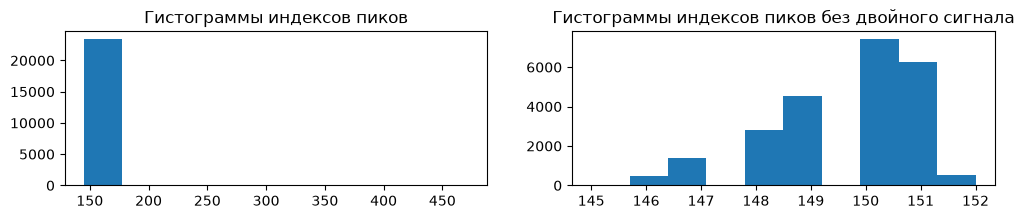

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 2))
axes[0].hist(signal_peaks, bins=10)
axes[1].hist(signal_peaks.drop([signal_with_far_peak_idx]), bins=10)
axes[0].set_title("Гистограммы индексов пиков")
axes[1].set_title("Гистограммы индексов пиков без двойного сигнала")
plt.show()

<Axes: title={'center': 'Двойной сигнал 1929'}, xlabel='Time, ns', ylabel='Bit ADC'>

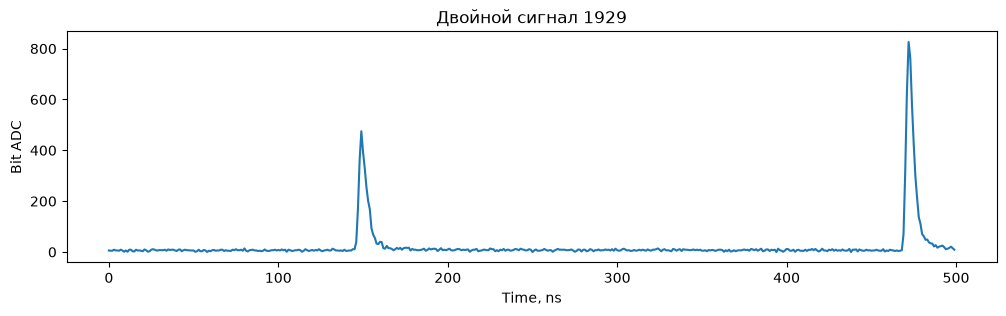

In [22]:
plot_plain_signal(df_raw.iloc[[1929], :].T, title="Двойной сигнал 1929")

Сигнал 19696 найти можно по долгому закрытию "окна", т.к. порог срабатывания для него находится ниже уровня шума. В результате, сигнал некорректно считается более длинным.

<Axes: title={'center': 'Двойной сигнал 19696'}, xlabel='Time, ns', ylabel='Bit ADC'>

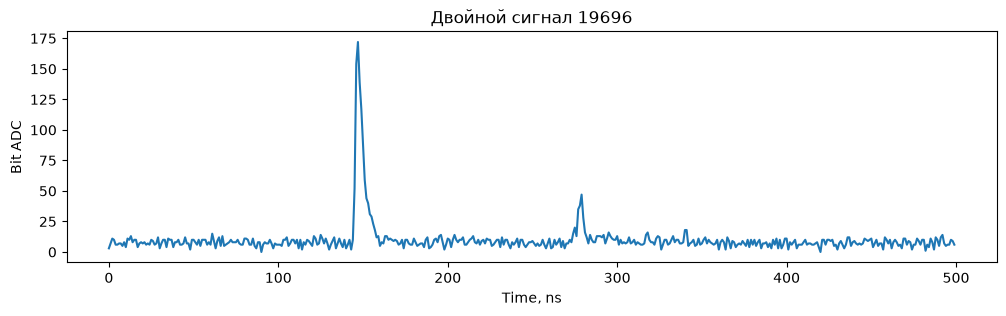

In [23]:
plot_plain_signal(df_raw.iloc[[19696], :].T, title="Двойной сигнал 19696")

## Предварительные выводы
- Данные нужно инвертировать и приводить к одной базе.
- Начало сигналов будем брать от индекса 140. Шум у сигналов с индексами 3321 и 11849 до 140-го индекса можно игнорировать, т.к. после 140-го они оба растут выше своих "шумных" пиков.
- Максимальный шум достигает значения 24. При расчёте индекса окончания сигнала нужно будет учитывать шум детектора для каждого сигнала на основе расчётного стандартного отклонения.
- В датасете есть сигналы с уплощёнными пиками. При расчёте времени высвечивании это нужно будет учитывать.
- В двойном сигнале с индексом 1929 для расчётов возьмём первый сигнал, а при кластеризации выставим ему неопределённый кластер.
- В двойном сигнале с индексом 19696 для расчётов отрежем хвост после 250.

## Построение базовых компонентов сигнала

In [9]:
df = pd.DataFrame({'data_array': df_raw.apply(lambda row: np.array(row.values), axis=1)})

In [10]:
signal_df = (df.pipe(lambda _df: calc_base_signal_components(_df)))
signal_df.head()

,data_array,signal_indices_in_data_array,signal_array,signal_own_indices,peak_idx,signal_start,amplitude,peak_idx_in_signal,noise_std,noise_threshold,signal_end,signal_area,signal_duration
0,"[10, 7, 6, 8, 12, 10, 6, 8, 10, 10, 10, 8, 6, ...","[140, 141, 142, 143, 144, 145, 146, 147, 148, ...","[12, 7, 12, 12, 10, 16, 67, 267, 452, 539, 452...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",149,140,539,9,2.731851,8.195553,200,4528.0,61
1,"[8, 6, 8, 2, 4, 6, 8, 6, 5, 7, 5, 5, 6, 4, 1, ...","[140, 141, 142, 143, 144, 145, 146, 147, 148, ...","[8, 8, 4, 5, 9, 9, 16, 155, 648, 1393, 1907, 1...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",150,140,1907,10,2.718643,8.155929,180,11751.0,41
2,"[10, 10, 8, 5, 10, 6, 6, 11, 7, 6, 7, 7, 7, 6,...","[140, 141, 142, 143, 144, 145, 146, 147, 148, ...","[12, 5, 2, 11, 18, 20, 48, 272, 943, 1889, 249...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",151,140,2566,11,2.416979,7.250936,198,16750.5,59
3,"[3, 9, 13, 7, 7, 9, 11, 9, 7, 11, 11, 7, 5, 10...","[140, 141, 142, 143, 144, 145, 146, 147, 148, ...","[11, 4, 12, 15, 11, 7, 51, 201, 404, 573, 534,...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",149,140,573,9,2.776946,8.330838,184,4392.5,45
4,"[5, 13, 5, 7, 1, 8, 5, 4, 12, 7, 6, 3, 6, 5, 8...","[140, 141, 142, 143, 144, 145, 146, 147, 148, ...","[5, 6, 8, 8, 4, 14, 38, 197, 824, 1532, 1800, ...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",150,140,1800,10,2.676618,8.029855,178,11386.5,39


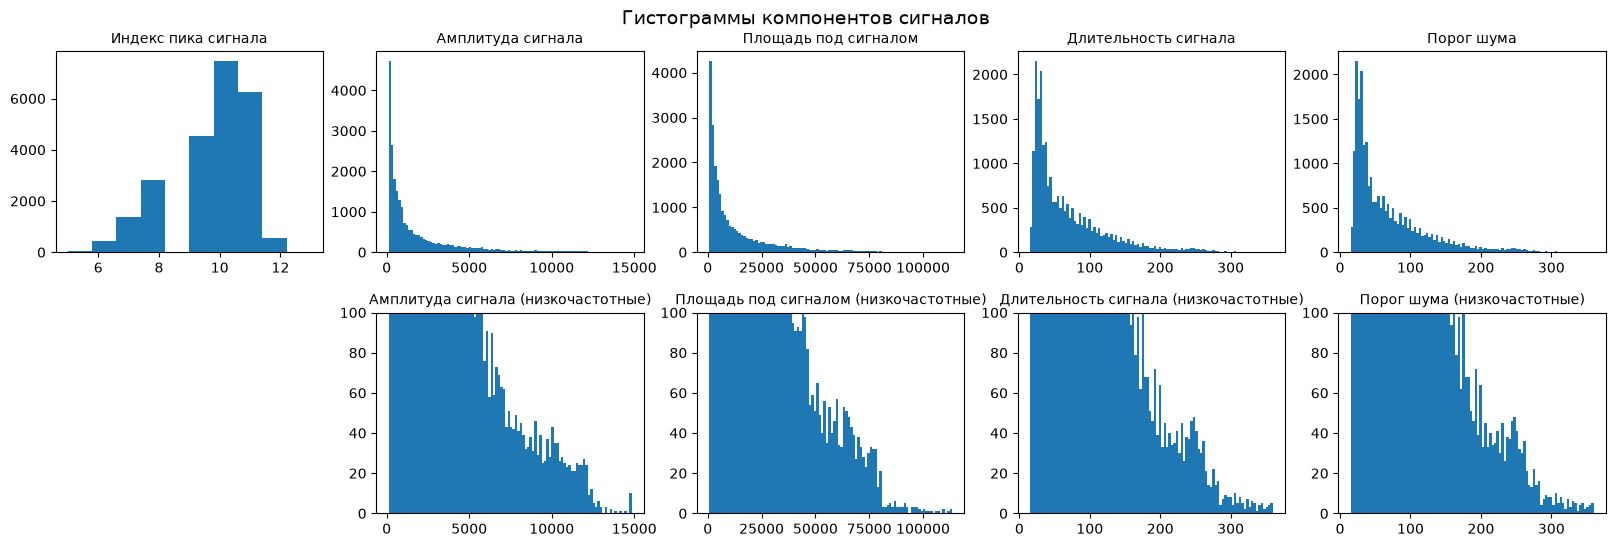

In [31]:
plt_h = partial(plot_hist, df=signal_df, bins=100, ymax=100)
fig, axes = plt.subplots(2, 5, figsize=(20, 6), gridspec_kw={'wspace': 0.20, 'hspace': 0.30})
fig.suptitle("Гистограммы компонентов сигналов", fontsize=14, y=0.95)
plt_h(col='peak_idx_in_signal', title="Индекс пика сигнала", bins=10, ax=axes[0][0])
ax_off(axes[1][0])
plt_h(col='amplitude', title="Амплитуда сигнала", ax=axes[0][1], ax_zoom=axes[1][1])
plt_h(col='signal_area', title="Площадь под сигналом", ax=axes[0][2], ax_zoom=axes[1][2])
plt_h(col='signal_duration', title="Длительность сигнала", ax=axes[0][3], ax_zoom=axes[1][3])
plt_h(col='signal_duration', title="Порог шума", ax=axes[0][4], ax_zoom=axes[1][4])
plt.show()

Проблем в компонентах сигналов не видно. Посмотрим на коррелиции.

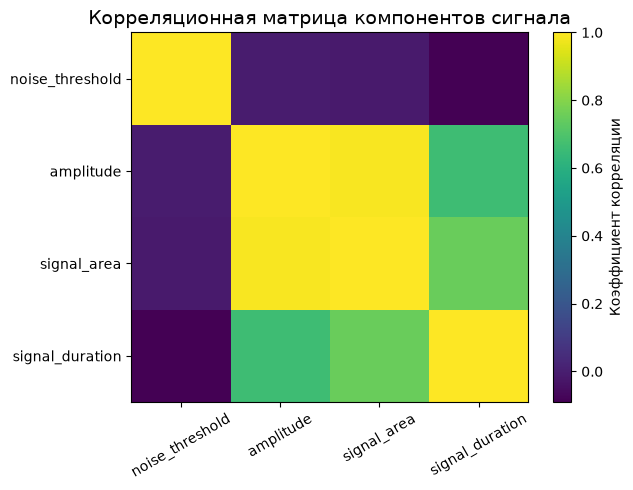

In [32]:
plot_corr_m(signal_df[['noise_threshold', 'amplitude', 'signal_area', 'signal_duration']])

Корреляции между амлитудой, площадью сигнала и его длительностью ожидаемы.

Низкая корреляция амлитудой, площадью сигнала, его длительности с порогом шума - это хорошо.

### Сохранение данных c базовыми компонентами

In [83]:
signal_df.to_parquet("../data/Run200_Wave_0_1_base_features.parquet")